In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [2]:
# base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'


In [2]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Cameroon/data'

In [4]:
# NUTS2 = 'Thrace'
# YEAR = '2024'

In [22]:
GID2_NAME = 'ExtNord'
YEAR = '2025_08'

In [23]:
# df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [24]:
df = pd.read_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled.csv', encoding=enc)

In [25]:
df.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,2025-01-01,10.103801,13.436551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,10.103801,13.436551,15339.0,NaN,2025-01-01,10.150046,13.450062,2024-12-31,2024-12-31,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,2025-01-02,10.103801,13.436551,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,2025-01-02,10.103801,13.436551,15339.0,NaN,2025-01-02,10.150046,13.450062,2025-01-01,2025-01-01,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,2025-01-02,10.103801,13.436551,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,2025-01-03,10.103801,13.436551,15299.0,14601.0,2025-01-03,10.150046,13.450062,2025-01-02,2025-01-02,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,2025-01-04,10.103801,13.436551,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,2025-01-04,10.103801,13.436551,15431.0,14619.0,2025-01-04,10.150046,13.450062,2025-01-03,2025-01-03,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,2025-01-05,10.103801,13.436551,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,2025-01-05,10.103801,13.436551,15179.0,14588.0,2025-01-05,10.150046,13.450062,2025-01-04,2025-01-04,0.39


In [26]:
date_columns = [col for col in df.columns if 'dt_placement' in col.lower() or 'date' in col.lower()]
print(f"Date columns: {date_columns}")
for col_name in date_columns:
    df[col_name] = pd.to_datetime(df[col_name])

# df['dt_placement'] = pd.to_datetime(df['dt_placement'])
# df['indices_image_date'] = pd.to_datetime(df['indices_image_date'])
# df['lst_image_date'] = pd.to_datetime(df['lst_image_date'])
# df['indices_image_date.1'] = pd.to_datetime(df['indices_image_date.1'])
# df['dt_placement_minus_1'] = pd.to_datetime(df['dt_placement_minus_1'])
# df['dt_placement_minus_1_avail'] = pd.to_datetime(df['dt_placement_minus_1_avail'])

Date columns: ['dt_placement', 'indices_image_date', 'lst_image_date', 'indices_image_date.1', 'dt_placement_minus_1', 'dt_placement_minus_1_avail']


Text(0.5, 1.0, 'Year: 2025')

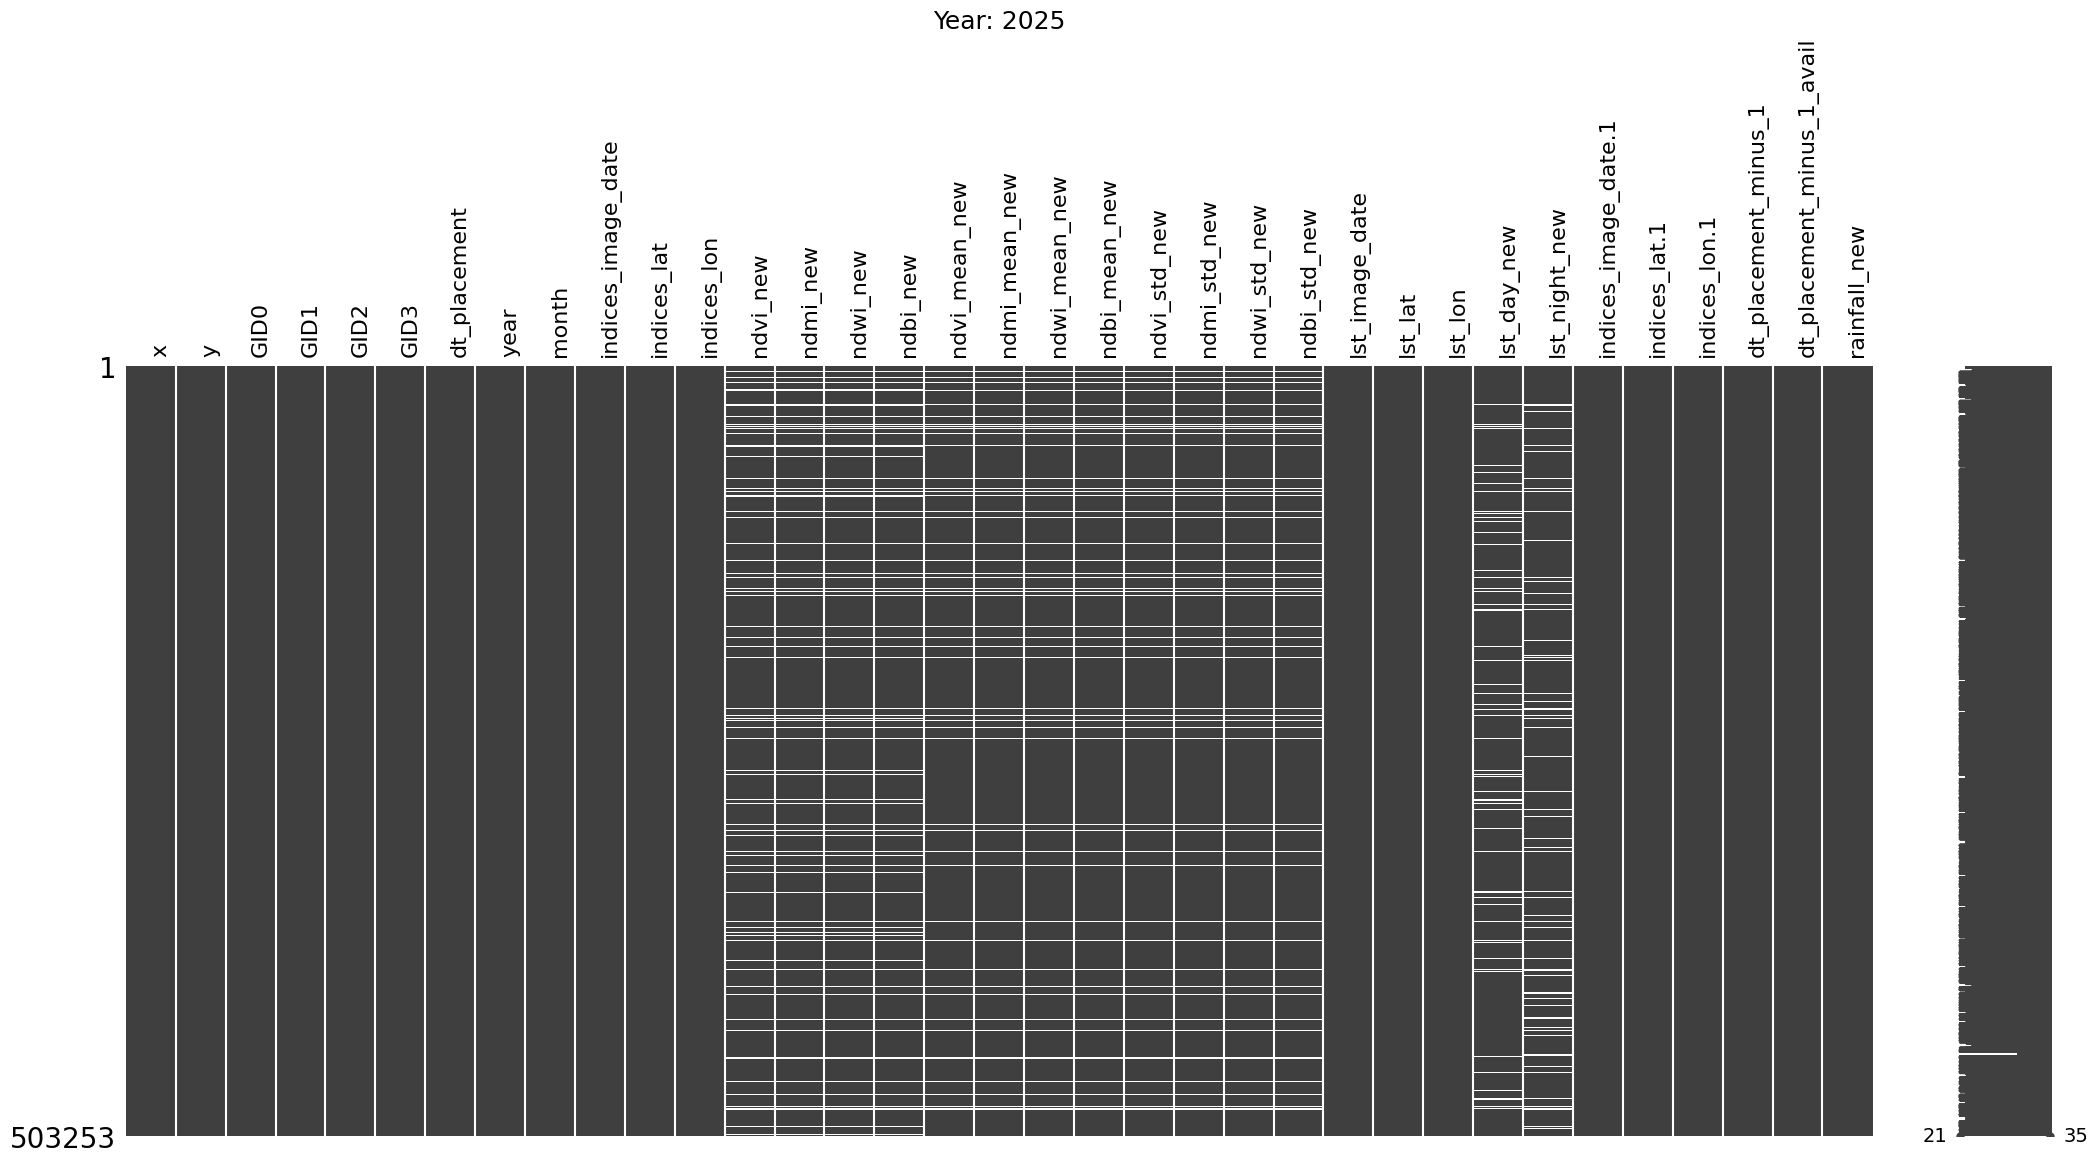

In [27]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df.year.iloc[0]}", fontsize=18)

In [28]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
12,ndvi_new,10.1557
13,ndmi_new,10.1557
14,ndwi_new,10.1557
15,ndbi_new,10.1557
16,ndvi_mean_new,7.9938
17,ndmi_mean_new,7.9938
18,ndwi_mean_new,7.9938
19,ndbi_mean_new,7.9950
20,ndvi_std_new,7.9938
21,ndmi_std_new,7.9938


In [29]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [30]:
describe_dataframe(df, remove_zeros=True)

,Column,Missing
10,ndvi,10.1557
11,ndmi,10.1557
12,ndwi,10.1557
13,ndbi,10.1557
14,ndvi_mean,7.9938
15,ndmi_mean,7.9938
16,ndwi_mean,7.9938
17,ndbi_mean,7.9950
18,ndvi_std,7.9938
19,ndmi_std,7.9938


In [31]:
df2 = df.copy()

In [32]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

In [33]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
10,ndvi,10.1557
11,ndmi,10.1557
12,ndwi,10.1557
13,ndbi,10.1557
14,ndvi_mean,7.9938
15,ndmi_mean,7.9938
16,ndwi_mean,7.9938
17,ndbi_mean,7.9950
18,ndvi_std,7.9938
19,ndmi_std,7.9938


In [34]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [35]:
df2.reset_index(drop=True, inplace=True)

In [36]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503248,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-27,2025,8,0.546955,0.172618,-0.419604,-0.172618,0.435715,0.222549,-0.328320,-0.222549,0.062261,0.067652,0.066262,0.067652,NaN,NaN,0.00
503249,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-28,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.00
503250,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-29,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.35
503251,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-30,2025,8,0.534420,0.169878,-0.407995,-0.169878,0.496937,0.183577,-0.379802,-0.183577,0.041321,0.038749,0.039112,0.038749,NaN,NaN,2.30


Text(0.5, 1.0, 'Year: 2025')

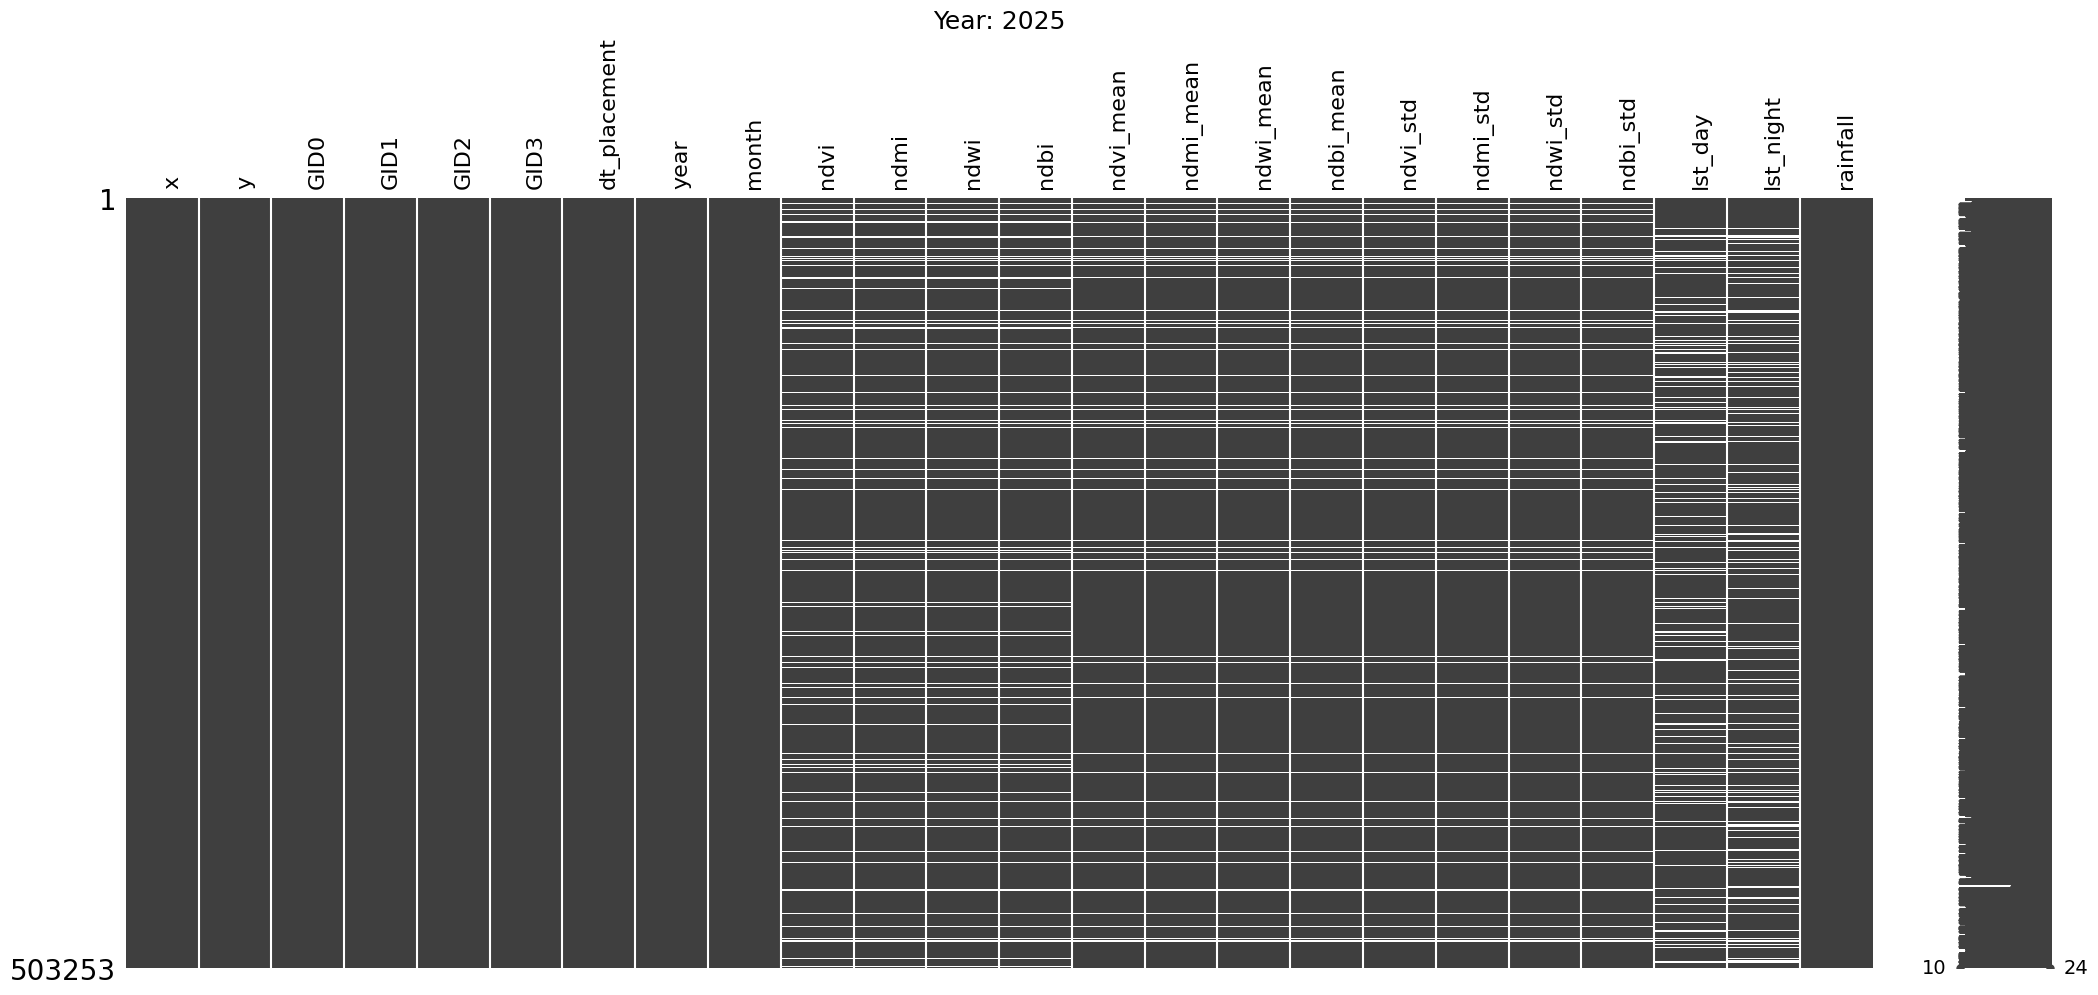

In [37]:
msno.matrix(df2, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {df2.year.iloc[0]}", fontsize=18)

In [38]:
#df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding='utf-8')

In [39]:
df2.to_csv(f'{base_folder}/{GID2_NAME}/CM_{GID2_NAME}_Timeline_{YEAR}_filled_cleaned.csv', encoding='utf-8')

In [40]:
df2

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15339.0,NaN,0.00
1,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-02,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15339.0,NaN,0.11
2,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-03,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15299.0,14601.0,1.25
3,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-04,2025,1,0.231926,-0.110994,-0.317592,0.110994,0.227468,-0.108451,-0.324187,0.108451,0.013564,0.013731,0.011438,0.013731,15431.0,14619.0,0.66
4,13.43483,10.10446,extreme nord,mayo-tsanaga,bourha,maboudji,2025-01-05,2025,1,0.231400,-0.144919,-0.319074,0.144919,0.229307,-0.145684,-0.323623,0.145684,0.008093,0.013163,0.007198,0.013163,15179.0,14588.0,0.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503248,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-27,2025,8,0.546955,0.172618,-0.419604,-0.172618,0.435715,0.222549,-0.328320,-0.222549,0.062261,0.067652,0.066262,0.067652,NaN,NaN,0.00
503249,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-28,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.00
503250,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-29,2025,8,0.552310,0.267328,-0.216691,-0.267328,0.557122,0.306295,-0.179481,-0.306295,0.060035,0.023811,0.061219,0.023811,NaN,NaN,0.35
503251,15.57371,10.02477,extreme nord,mayo-danay,guere,nouldaina,2025-08-30,2025,8,0.534420,0.169878,-0.407995,-0.169878,0.496937,0.183577,-0.379802,-0.183577,0.041321,0.038749,0.039112,0.038749,NaN,NaN,2.30
